## Import Libraries and Configure GPU

Imports the required libraries for data processing, deep learning, model evaluation, visualization, and configures PyTorch to use a GPU if available.

In [5]:
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Dataset path and cysteine labels
Cysteine value per cultivar from HPLC. One value per cultivar, shared by all 324 of its spectra.

In [7]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

## Read one Raman spectrum
Parses a B and W Tek txt file. Returns Raman shifts and dark subtracted intensities.

In [9]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

## Preprocessing combinations
Eight SG based combinations. SG plus MSC is the best performer under LOCO for both PLSR and CNN.

In [11]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc(X):
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Preprocessing combinations: {len(preprocessing_combos)}")

Preprocessing combinations: 8


## Build Matrix:
Loads all spectral data and constructs the feature matrix, target values, and cultivar labels for model training.

In [10]:
def build_matrix():
    X, y, cult = [], [], []
    for folder, info in CULTIVARS.items():
        fpath = DATASET_DIR / folder
        if not fpath.exists():
            print(f"missing folder: {folder}")
            continue
        n = 0
        for f in fpath.rglob("*.txt"):
            rs, intens = read_spectrum(f)
            if len(intens) == 1530:
                X.append(intens); y.append(info["cys"]); cult.append(info["label"]); n += 1
        print(f"{info['label']:16s} {n} spectra")
    return np.array(X), np.array(y), np.array(cult)

X, y, cult = build_matrix()
print(f"\nX={X.shape}, cultivars={len(np.unique(cult))}, cys span={y.max()-y.min():.4f}")

AAC Chrome       324 spectra
AAC Lacombe      324 spectra
AAC Liscard      324 spectra
CDC Amarillo     324 spectra
CDC Athabasca    324 spectra
CDC Canary       324 spectra
CDC Dakota       324 spectra
CDC Golden       324 spectra
CDC Greenwater   324 spectra
CDC Inca         324 spectra
CDC Jasper       324 spectra
CDC Lewochko     324 spectra
CDC Meadow       324 spectra
CDC Patrick      324 spectra
CDC Saffron      324 spectra
CDC Spectrum     324 spectra
CDC Spruce       324 spectra
CDC Striker      324 spectra
CDC Tetris       324 spectra
Redbat 88        324 spectra

X=(6480, 1530), cultivars=20, cys span=0.0612


## GSx greedy selection:
Generates a GSX (Kennard Stone) ordering of cultivars by iteratively selecting the cultivar that is farthest from those already selected, maximizing spectral diversity.

In [15]:
def gsx_order(cultivar_means):
    n = cultivar_means.shape[0]
    centre = cultivar_means.mean(axis=0, keepdims=True)
    first = int(np.argmin(np.linalg.norm(cultivar_means - centre, axis=1)))
    selected, remaining = [first], [i for i in range(n) if i != first]
    while remaining:
        best_i, best_d = None, -np.inf
        for i in remaining:
            d = min(np.linalg.norm(cultivar_means[i] - cultivar_means[s]) for s in selected)
            if d > best_d:
                best_d, best_i = d, i
        selected.append(best_i); remaining.remove(best_i)
    return selected

### Experiment Execution and Evaluation

Evaluates PLSR performance using GSX selected and random training cultivar subsets across different training budgets, then returns the performance metrics as a DataFrame.

In [17]:
def evaluate_subset(X, y, cult, train_cultivars, max_components=18):
    tr = np.isin(cult, train_cultivars); te = ~tr
    if te.sum() == 0:
        return np.nan, np.nan, np.nan
    n_comp = max(1, int(min(max_components, X[tr].shape[1], tr.sum() - 1)))
    model = PLSRegression(n_components=n_comp).fit(X[tr], y[tr])
    pred = model.predict(X[te]).ravel()
    rmse = np.sqrt(mean_squared_error(y[te], pred))
    r2 = r2_score(y[te], pred)
    rpd = y[te].std() / rmse if rmse > 0 else np.nan
    return r2, rmse, rpd

def run_experiment(X, y, cult, n_random_seeds=30, max_components=18):
    cultivars = np.array(sorted(np.unique(cult)))
    n_cult = len(cultivars)
    budgets = list(range(2, n_cult - 2, 2))          
    means = np.vstack([X[cult == c].mean(axis=0) for c in cultivars])
    ranked = cultivars[gsx_order(means)]
    rows = []
    for k in budgets:
        r2, rmse, rpd = evaluate_subset(X, y, cult, ranked[:k], max_components)
        rows.append(dict(budget=k, method="greedy", r2=r2, rmse=rmse, rpd=rpd))
        r2s, rmses, rpds = [], [], []
        for seed in range(n_random_seeds):
            pick = np.random.default_rng(seed).choice(cultivars, k, replace=False)
            a, b, c = evaluate_subset(X, y, cult, pick, max_components)
            r2s.append(a); rmses.append(b); rpds.append(c)
        rows.append(dict(budget=k, method="random", r2=np.nanmean(r2s),
                         rmse=np.nanmean(rmses), rpd=np.nanmean(rpds), r2_std=np.nanstd(r2s)))
    return pd.DataFrame(rows), ranked

### Run All Preprocessing Experiments

Applies all preprocessing methods, evaluates GSX and random cultivar selection strategies, and saves the performance results and GSX cultivar orders for comparison.

In [18]:
def run_all(X, y, cult, n_random_seeds=30, max_components=18):
    all_results, all_orders = {}, {}
    for name, fn in preprocessing_combos.items():
        Xp = fn(X.astype(float))
        res, ranked = run_experiment(Xp, y, cult, n_random_seeds, max_components)
        res["prep"] = name
        all_results[name] = res
        all_orders[name] = list(ranked)
        g = res[res.method == "greedy"]
        print(f"{name:20s} greedy R2: {g.r2.min():.2f} to {g.r2.max():.2f}")
    return pd.concat(all_results.values(), ignore_index=True), all_orders

results, orders = run_all(X, y, cult, n_random_seeds=30, max_components=18)
results.to_csv("greedy_vs_random_all_prep.csv", index=False)

print("\nGSx order by preprocessing:")
order_df = pd.DataFrame(orders)
print(order_df.to_string())
order_df.to_csv("gsx_order_by_prep.csv", index=False)

SG + SNV             greedy R2: -3.57 to -0.33
SG + MSC             greedy R2: -0.87 to -0.19
SG + 1st Deriv       greedy R2: -4.12 to -0.33
SG + 2nd Deriv       greedy R2: -4.16 to -0.15
SG + SNV + 1st Der   greedy R2: -4.72 to -1.24
SG + SNV + 2nd Der   greedy R2: -4.50 to -1.73
SG + MSC + 1st Der   greedy R2: -3.42 to -0.66
SG + MSC + 2nd Der   greedy R2: -4.46 to -1.04

GSx order by preprocessing:
          SG + SNV        SG + MSC  SG + 1st Deriv  SG + 2nd Deriv SG + SNV + 1st Der SG + SNV + 2nd Der SG + MSC + 1st Der SG + MSC + 2nd Der
0   CDC Greenwater     CDC Patrick      CDC Meadow      CDC Meadow         AAC Chrome         AAC Chrome         AAC Chrome         AAC Chrome
1      AAC Liscard     AAC Liscard      CDC Canary      CDC Canary        AAC Liscard        AAC Liscard        AAC Liscard        AAC Liscard
2       CDC Canary     CDC Saffron     CDC Striker     CDC Striker         CDC Canary       CDC Spectrum         CDC Canary       CDC Spectrum
3      CDC Saffron     

## CNN architecture
Same 1D CNN used in CNN.ipynb. Four convolutional blocks with batch normalisation, then two fully connected layers.

In [22]:
class CNN1D(nn.Module):
    def __init__(self, input_size=1530):
        super(CNN1D, self).__init__()

        # ── Convolutional blocks ──
        self.conv_blocks = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 2
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 3
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 4
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        # Calculate flattened size after conv blocks
        # 1530 → /2 → /2 → /2 → /2 = 1530/16 = 95
        self.flat_size = 128 * (input_size // 16)

        # ── Fully connected layers ──
        self.fc_layers = nn.Sequential(
            nn.Linear(self.flat_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)   # output = single cysteine value
        )

    def forward(self, x):
        # x shape: (batch, 1530)
        x = x.unsqueeze(1)          # → (batch, 1, 1530) for Conv1d
        x = self.conv_blocks(x)     # → (batch, 128, 95)
        x = x.view(x.size(0), -1)  # → flatten: (batch, 12160)
        x = self.fc_layers(x)       # → (batch, 1)
        return x.squeeze(1)         # → (batch,)

# Test the architecture
model_test = CNN1D(input_size=1530)
print(model_test)
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters()):,}")

# Test with dummy input
dummy = torch.randn(4, 1530)
out   = model_test(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}  ← should be (4,)")

CNN1D(
  (conv_blocks): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): 

## CNN training loop
Huber loss, AdamW, OneCycle schedule. Keeps the weights with the lowest validation loss.

In [23]:
def train_cnn(model, X_train, y_train, X_val, y_val,
              epochs=100, batch_size=32, lr=1e-4):

    # Convert to tensors
    X_tr  = torch.FloatTensor(X_train).to(device)
    y_tr  = torch.FloatTensor(y_train).to(device)
    X_v   = torch.FloatTensor(X_val).to(device)
    y_v   = torch.FloatTensor(y_val).to(device)

    # DataLoader for batching
    dataset    = TensorDataset(X_tr, y_tr)
    loader     = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Loss and optimiser
    criterion  = nn.SmoothL1Loss(beta=0.02)   
    optimizer  = optim.AdamW(model.parameters(),
                             lr=lr, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.OneCycleLR(
                     optimizer, max_lr=lr,
                     steps_per_epoch=len(loader),
                     epochs=epochs)

    model.to(device)
    model.train()

    best_val_loss = np.inf
    best_weights  = None
    train_losses  = []
    val_losses    = []

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(loader)
        train_losses.append(avg_train_loss)

        # ── Validation ──
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_v)
            val_loss   = criterion(y_val_pred, y_v).item()
        val_losses.append(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} — "
                  f"Train Loss: {avg_train_loss:.5f}  "
                  f"Val Loss: {val_loss:.5f}")

    # Restore best weights
    model.load_state_dict(best_weights)
    print(f"\nBest validation loss: {best_val_loss:.5f}")

    return model, train_losses, val_losses

## Cultivar tracking and selection methods
Builds the cult array so every spectrum knows which cultivar it came from, since selection happens at cultivar level.

Two selection strategies:
- **GSx** picks the most representative cultivar first, then repeatedly the one most different from those already picked. Uses spectra only.
- **iGS** adds label distance to the criterion, so it also favours cultivars at the edges of the cysteine range.

In [26]:
import numpy as np, pandas as pd, io, contextlib
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

cult = []
for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        continue
    for f in folder_path.rglob("*.txt"):
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            cult.append(meta['label'])
cult = np.array(cult)
assert len(cult) == len(X) == len(y), "cult not aligned with X/y"

def gsx_order(means):
    n = len(means); centre = means.mean(0, keepdims=True)
    first = int(np.argmin(np.linalg.norm(means - centre, axis=1)))
    sel, rem = [first], [i for i in range(n) if i != first]
    while rem:
        best = max(rem, key=lambda i: min(np.linalg.norm(means[i]-means[s]) for s in sel))
        sel.append(best); rem.remove(best)
    return sel

def igs_order(means, yv, max_comp=5):
    n = len(means); centre = means.mean(0, keepdims=True)
    first = int(np.argmin(np.linalg.norm(means - centre, axis=1)))
    sel, rem = [first], [i for i in range(n) if i != first]
    while rem:
        if len(sel) < 2:
            best = max(rem, key=lambda i: min(np.linalg.norm(means[i]-means[s]) for s in sel))
        else:
            Xl, yl = means[sel], yv[sel]
            nc = max(1, min(max_comp, len(sel)-1, Xl.shape[1]))
            pred = PLSRegression(n_components=nc).fit(Xl, yl).predict(means).ravel()
            best, best_s = None, -np.inf
            for i in rem:
                dx = min(np.linalg.norm(means[i]-means[s]) for s in sel)
                dy = min(abs(pred[i]-yv[s]) for s in sel)
                if dx*dy > best_s:
                    best_s, best = dx*dy, i
        sel.append(best); rem.remove(best)
    return sel

## Evaluators and the budget sweep
Trains on the selected cultivars and tests pooled on all remaining ones.

The CNN validation split is drawn from the training cultivars, never the held out ones. This avoids the checkpoint selection leakage present in the original LOCO loop.

In [27]:
def evaluate_plsr(Xp, y, cult, train_cultivars, max_components=18):
    tr = np.isin(cult, train_cultivars); te = ~tr
    if te.sum() == 0: return np.nan, np.nan, np.nan
    nc = max(1, int(min(max_components, Xp[tr].shape[1], tr.sum()-1)))
    pred = PLSRegression(n_components=nc).fit(Xp[tr], y[tr]).predict(Xp[te]).ravel()
    rmse = np.sqrt(mean_squared_error(y[te], pred)); r2 = r2_score(y[te], pred)
    return r2, rmse, (y[te].std()/rmse if rmse>0 else np.nan)

def evaluate_cnn(Xp, y, cult, train_cultivars, epochs, seed):
    import torch
    tr = np.isin(cult, train_cultivars); te = ~tr
    if te.sum() == 0: return np.nan, np.nan, np.nan
    # leakage fix: validation comes from the TRAINING cultivars, never the held out ones
    Xt, Xv, yt, yv = train_test_split(Xp[tr], y[tr], test_size=0.15, random_state=seed)
    torch.manual_seed(seed)
    model = CNN1D(input_size=Xp.shape[1]).to(device)
    with contextlib.redirect_stdout(io.StringIO()):       # silence per epoch prints
        model, _, _ = train_cnn(model, Xt, yt, Xv, yv, epochs=epochs, batch_size=32, lr=1e-4)
    model.eval()
    with torch.no_grad():
        pred = model(torch.FloatTensor(Xp[te]).to(device)).cpu().numpy()
    rmse = np.sqrt(mean_squared_error(y[te], pred)); r2 = r2_score(y[te], pred)
    return r2, rmse, (y[te].std()/rmse if rmse>0 else np.nan)

def run_curve(Xp, y, cult, ranked, model="plsr", n_seeds=30, epochs=60, max_components=18):
    cultivars = np.array(sorted(np.unique(cult))); n_cult = len(cultivars)
    budgets = list(range(2, n_cult-2, 2))          # keep >=4 held out cultivars
    rows = []
    for k in budgets:
        g = (evaluate_plsr(Xp, y, cult, ranked[:k], max_components) if model=="plsr"
             else evaluate_cnn(Xp, y, cult, ranked[:k], epochs, 0))
        rows.append(dict(budget=k, method="greedy", model=model, r2=g[0], rmse=g[1], rpd=g[2]))
        r2s, rmses, rpds = [], [], []
        for s in range(n_seeds):
            pick = np.random.default_rng(s).choice(cultivars, k, replace=False)
            ev = (evaluate_plsr(Xp, y, cult, pick, max_components) if model=="plsr"
                  else evaluate_cnn(Xp, y, cult, pick, epochs, s))
            r2s.append(ev[0]); rmses.append(ev[1]); rpds.append(ev[2])
        rows.append(dict(budget=k, method="random", model=model, r2=np.nanmean(r2s),
                         rmse=np.nanmean(rmses), rpd=np.nanmean(rpds), r2_std=np.nanstd(r2s)))
        print(f"  {model} budget {k:2d} done")
    return pd.DataFrame(rows)

## iGS selection order on SG plus MSC
The order to send cultivars for HPLC. The cys_rank column shows where each sits in the cysteine range, so you can see whether selection favours the extremes.

In [35]:
PREP = "SG + MSC"
Xp = preprocessing_combos[PREP](X.astype(float))

cultivars = np.array(sorted(np.unique(cult)))
means = np.vstack([Xp[cult==c].mean(0) for c in cultivars])
yv    = np.array([y[cult==c][0] for c in cultivars])

igs = cultivars[igs_order(means, yv)]
gsx = cultivars[gsx_order(means)]
cys_rank = {c:r for r,c in enumerate(sorted(cultivars, key=lambda c: y[cult==c][0]), 1)}

print(f"iGS order on {PREP} (send these for HPLC first):")
for i, c in enumerate(igs, 1):
    print(f"  {i:2d}. {c:16s} cys_rank {cys_rank[c]}/{len(cultivars)}")

iGS order on SG + MSC (send these for HPLC first):
   1. CDC Patrick      cys_rank 8/20
   2. AAC Liscard      cys_rank 5/20
   3. CDC Meadow       cys_rank 1/20
   4. CDC Saffron      cys_rank 16/20
   5. CDC Golden       cys_rank 18/20
   6. CDC Canary       cys_rank 2/20
   7. AAC Lacombe      cys_rank 9/20
   8. CDC Spruce       cys_rank 14/20
   9. CDC Tetris       cys_rank 12/20
  10. AAC Chrome       cys_rank 4/20
  11. CDC Athabasca    cys_rank 10/20
  12. CDC Lewochko     cys_rank 11/20
  13. CDC Spectrum     cys_rank 20/20
  14. CDC Inca         cys_rank 19/20
  15. CDC Amarillo     cys_rank 17/20
  16. CDC Greenwater   cys_rank 15/20
  17. Redbat 88        cys_rank 3/20
  18. CDC Dakota       cys_rank 6/20
  19. CDC Jasper       cys_rank 7/20
  20. CDC Striker      cys_rank 13/20


## Quick run (5 seeds, 60 epochs)
Fast pass to check the shape of the curves. Too noisy to report, use the 30 seed run below for final numbers.

In [29]:
CNN_EPOCHS = 60      
CNN_SEEDS  = 5      

print("PLSR curve (full seeds, free):")
res_plsr = run_curve(Xp, y, cult, igs, model="plsr", n_seeds=30, max_components=18)

print(f"\nCNN curve on {PREP} ({CNN_SEEDS} random seeds, {CNN_EPOCHS} epochs each):")
res_cnn  = run_curve(Xp, y, cult, igs, model="cnn", n_seeds=CNN_SEEDS, epochs=CNN_EPOCHS)

results = pd.concat([res_plsr, res_cnn], ignore_index=True)
results.to_csv("igs_plsr_cnn_curves.csv", index=False)
print("\n", results.to_string(index=False))

PLSR curve (full seeds, free):
  plsr budget  2 done
  plsr budget  4 done
  plsr budget  6 done
  plsr budget  8 done
  plsr budget 10 done
  plsr budget 12 done
  plsr budget 14 done
  plsr budget 16 done

CNN curve on SG + MSC (5 random seeds, 60 epochs each):
  cnn budget  2 done
  cnn budget  4 done
  cnn budget  6 done
  cnn budget  8 done
  cnn budget 10 done
  cnn budget 12 done
  cnn budget 14 done
  cnn budget 16 done

  budget method model        r2     rmse      rpd   r2_std
      2 greedy  plsr -0.219789 0.018743 0.905436      NaN
      2 random  plsr -1.815571 0.025261 0.718386 2.949332
      4 greedy  plsr -2.317454 0.029821 0.549032      NaN
      4 random  plsr -2.643714 0.028440 0.600159 2.131283
      6 greedy  plsr -1.101197 0.022012 0.689869      NaN
      6 random  plsr -2.034824 0.026159 0.679548 2.935944
      8 greedy  plsr -0.811734 0.021985 0.742938      NaN
      8 random  plsr -1.513487 0.023877 0.686751 1.317663
     10 greedy  plsr -1.167242 0.023084 0.67

## Plot the label efficiency curves
iGS greedy against random selection, one panel per model. Shaded band is the standard deviation across random seeds.

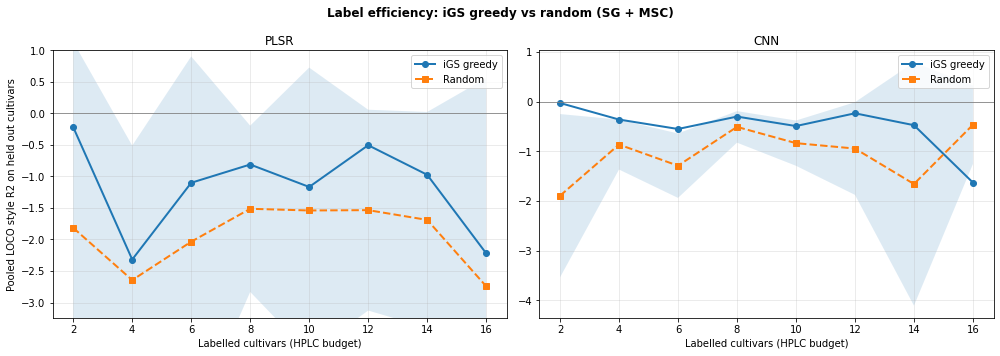

In [30]:
import matplotlib.pyplot as plt

def plot_two(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for ax, mdl in zip(axes, ["plsr", "cnn"]):
        sub = results[results.model == mdl]
        g = sub[sub.method=="greedy"]; r = sub[sub.method=="random"]
        ax.plot(g.budget, g.r2, "o-", lw=2, label="iGS greedy")
        ax.plot(r.budget, r.r2, "s--", lw=2, label="Random")
        if "r2_std" in r:
            ax.fill_between(r.budget, r.r2-r.r2_std, r.r2+r.r2_std, alpha=0.15)
        ax.axhline(0, color="grey", lw=0.8)
        ax.set_title(mdl.upper()); ax.set_xlabel("Labelled cultivars (HPLC budget)")
        ax.grid(alpha=0.3); ax.legend()
    axes[0].set_ylabel("Pooled LOCO style R2 on held out cultivars")
    lo = max(results.r2.min()-0.5, -6); axes[0].set_ylim(lo, 1.0)
    fig.suptitle("Label efficiency: iGS greedy vs random (SG + MSC)", fontweight="bold")
    fig.tight_layout(); plt.savefig("igs_label_efficiency.png", dpi=150); plt.show()

plot_two(results)

## Final run (30 seeds, 100 epochs)

Result: iGS greedy beats random at all eight budgets for both models. Best CNN greedy point is budget 12 at R2 minus 0.193.

All values stay negative against the full 20 cultivar CNN at LOCO R2 0.736, so no subset recovers the full model. Selection method helps, but coverage is what the data needs.

Note that each budget tests on a different number of held out cultivars, so values are comparable between greedy and random at a given budget, not across budgets.

In [31]:
CNN_EPOCHS = 100      
CNN_SEEDS  = 30   

print("PLSR curve (full seeds, free):")
res_plsr = run_curve(Xp, y, cult, igs, model="plsr", n_seeds=30, max_components=18)

print(f"\nCNN curve on {PREP} ({CNN_SEEDS} random seeds, {CNN_EPOCHS} epochs each):")
res_cnn  = run_curve(Xp, y, cult, igs, model="cnn", n_seeds=CNN_SEEDS, epochs=CNN_EPOCHS)

results = pd.concat([res_plsr, res_cnn], ignore_index=True)
results.to_csv("igs_plsr_cnn_curves.csv", index=False)
print("\n", results.to_string(index=False))

PLSR curve (full seeds, free):
  plsr budget  2 done
  plsr budget  4 done
  plsr budget  6 done
  plsr budget  8 done
  plsr budget 10 done
  plsr budget 12 done
  plsr budget 14 done
  plsr budget 16 done

CNN curve on SG + MSC (30 random seeds, 100 epochs each):
  cnn budget  2 done
  cnn budget  4 done
  cnn budget  6 done
  cnn budget  8 done
  cnn budget 10 done
  cnn budget 12 done
  cnn budget 14 done
  cnn budget 16 done

  budget method model        r2     rmse      rpd   r2_std
      2 greedy  plsr -0.219789 0.018743 0.905436      NaN
      2 random  plsr -1.815571 0.025261 0.718386 2.949332
      4 greedy  plsr -2.317454 0.029821 0.549032      NaN
      4 random  plsr -2.643714 0.028440 0.600159 2.131283
      6 greedy  plsr -1.101197 0.022012 0.689869      NaN
      6 random  plsr -2.034824 0.026159 0.679548 2.935944
      8 greedy  plsr -0.811734 0.021985 0.742938      NaN
      8 random  plsr -1.513487 0.023877 0.686751 1.317663
     10 greedy  plsr -1.167242 0.023084 0.

## Final label efficiency plot

iGS greedy against random selection at each HPLC budget, one panel per model. Shaded band is one standard deviation across the 30 random seeds. Green dotted line is the full data LOCO result with all 20 cultivars labelled.

The gap between every curve and the green line is the finding: no subset recovers the full model. iGS is reliably better than random at choosing which cultivars to send, but coverage is what limits performance here, not the selection method.

Greedy is one run per budget while random is averaged over 30, so greedy has no band. The trend is fair but the comparison is not seed matched.

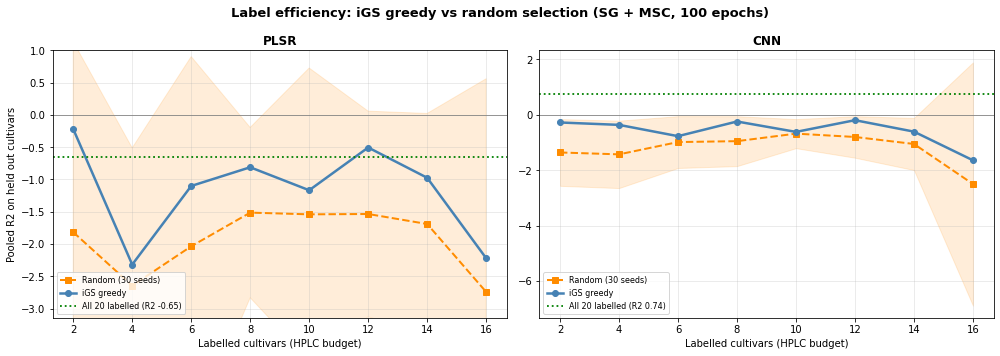

saved igs_label_efficiency_final.png


In [36]:
import matplotlib.pyplot as plt

# full data LOCO reference (all 20 cultivars labelled)
FULL_REF = {"plsr": -0.65, "cnn": 0.7361}

def plot_final(results, fname="igs_label_efficiency_final.png"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for ax, mdl in zip(axes, ["plsr", "cnn"]):
        sub = results[results.model == mdl]
        g = sub[sub.method == "greedy"]
        r = sub[sub.method == "random"]
        ax.fill_between(r.budget, r.r2 - r.r2_std, r.r2 + r.r2_std,
                        alpha=0.15, color="darkorange")
        ax.plot(r.budget, r.r2, "s--", lw=2, color="darkorange",
                label="Random (30 seeds)")
        ax.plot(g.budget, g.r2, "o-", lw=2.5, color="steelblue",
                label="iGS greedy")
        ax.axhline(FULL_REF[mdl], color="green", ls=":", lw=1.8,
                   label=f"All 20 labelled (R2 {FULL_REF[mdl]:.2f})")
        ax.axhline(0, color="grey", lw=0.8)
        ax.set_title(mdl.upper(), fontweight="bold")
        ax.set_xlabel("Labelled cultivars (HPLC budget)")
        ax.set_xticks(sorted(g.budget.unique()))
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc="lower left")

    axes[0].set_ylabel("Pooled R2 on held out cultivars")
    lo = max(results.r2.min() - 0.4, -6)
    axes[0].set_ylim(lo, 1.0)
    fig.suptitle("Label efficiency: iGS greedy vs random selection (SG + MSC, 100 epochs)",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {fname}")

plot_final(results)